# Class Balancing
## 1) Purpose
The purpose of this notebook is to evaluate class imbalance in our dataset for later computational balancing using **Synthetic Minority Over-Sampling Technique** (SMOTE).
## 2) Procedure
### 2.1) Data Visualization
Based on a preliminary search of our data the no appendicitis and appendicitis cases are relatively balanced. However, we noticed that only a few of the

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
from data_pp import appendicitis_pp

In [2]:
# Load data files
raw_data_path = "data/app_data.xlsx"
# Preprocess
data = appendicitis_pp(raw_data_path)

All diagnosis labels are 0 or 1 with no NaN
All non-NaN values are numeric
Preprocessing Done


In [3]:
# Plot styles
plt.rcParams.update({
    # Figure
    'figure.figsize':        (6, 5),
    'figure.dpi':            150,

    # Axes
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'axes.titlepad':         12,
    'axes.titlesize':        13,
    'axes.titleweight':      'bold',
    'axes.labelsize':        11,

    # Ticks
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,

    # Legend
    'legend.frameon':        False,
    'legend.fontsize':       9,

    # Layout
    'figure.autolayout':     True,   # equivalent to tight_layout()
})

# General palette
PALETTE = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377',
           '#CC3311', '#009988', '#BBBBBB']

# Diagnosis-specific colors (reuse across plots)
DIAG_COLORS = {
    'No Appendicitis': {
        'Conservative': '#0077BB',
        'Surgery':      '#66BBEE',
    },
    'Appendicitis': {
        'Conservative': '#EE7733',
        'Surgery':      '#F4B27A',
    }
}

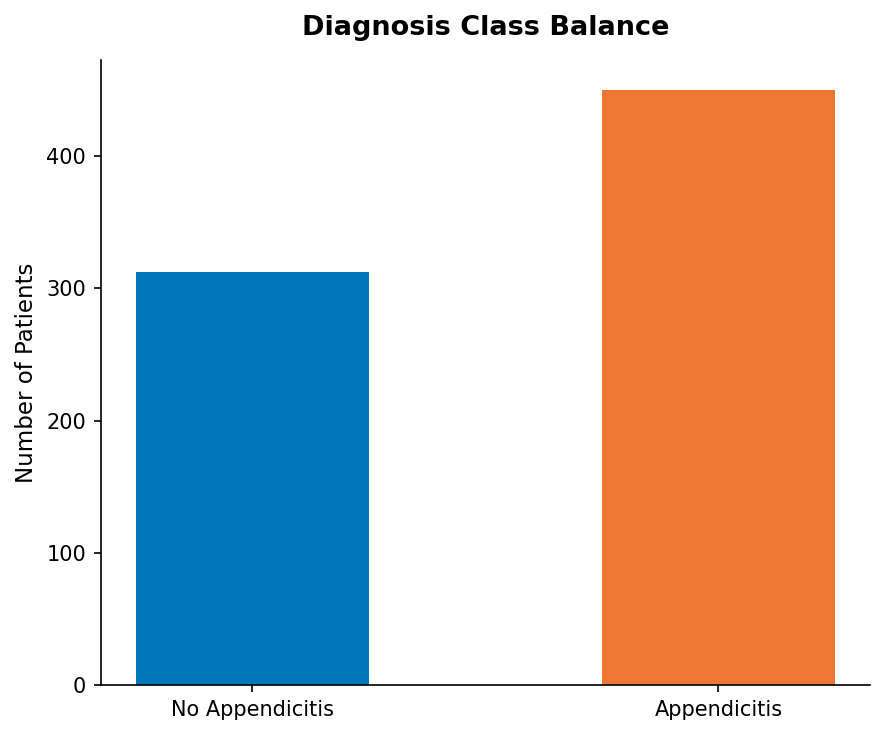

In [15]:
# First visualize general class imbalance
fig, ax = plt.subplots()

ax.bar(data["Diagnosis"].value_counts().index,
       data["Diagnosis"].value_counts().values,
       color=['#EE7733', '#0077BB'], width=0.5)
ax.set_xticks([0, 1], ['No Appendicitis', 'Appendicitis'])
ax.set_ylabel("Number of Patients")
ax.set_title("Diagnosis Class Balance")

plt.show()

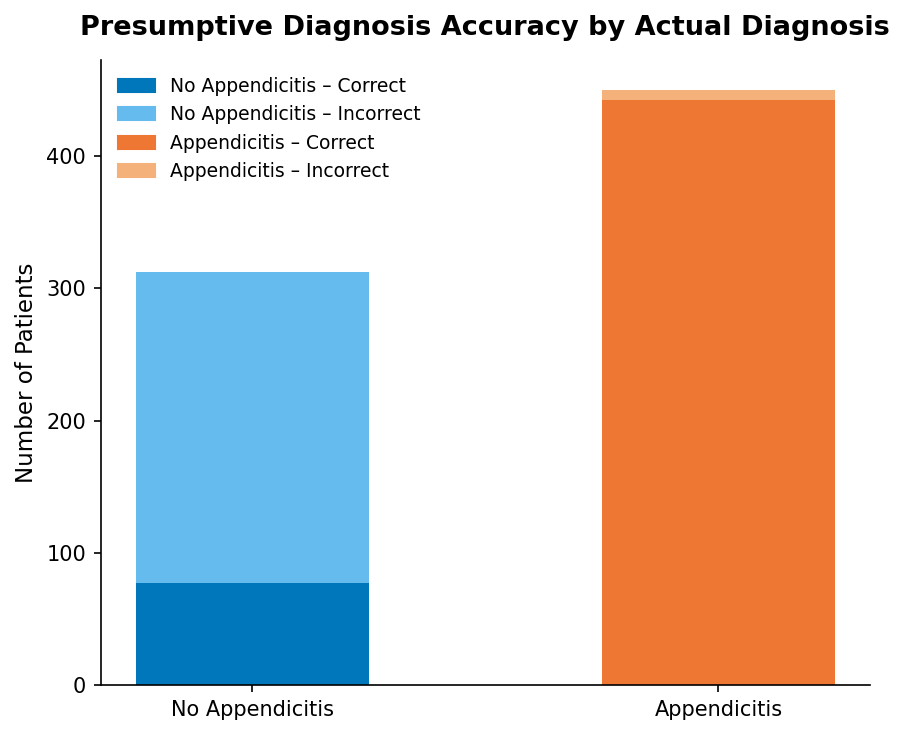

In [25]:
# Count combinations of actual diagnosis and whether presumptive was correct
data['correct'] = (data['Diagnosis'] == data['Diagnosis_Presumptive']).astype(int)

counts = data.groupby(['Diagnosis', 'correct']).size().unstack(fill_value=0)
counts.index = ['No Appendicitis', 'Appendicitis']
counts.columns = ['Incorrect', 'Correct']

# Color scheme — darker = correct, lighter = incorrect
DIAG_COLORS = {
    'No Appendicitis': {
        'Correct':   '#0077BB',  # full blue
        'Incorrect': '#66BBEE',  # light blue
    },
    'Appendicitis': {
        'Correct':   '#EE7733',  # full orange
        'Incorrect': '#F4B27A',  # light orange
    }
}

fig, ax = plt.subplots()
x = np.arange(len(counts))

for i, diagnosis in enumerate(counts.index):
    correct   = counts.loc[diagnosis, 'Correct']
    incorrect = counts.loc[diagnosis, 'Incorrect']
    ax.bar(x[i], correct,   width=0.5, color=DIAG_COLORS[diagnosis]['Correct'])
    ax.bar(x[i], incorrect, width=0.5, bottom=correct, color=DIAG_COLORS[diagnosis]['Incorrect'])

ax.set_title('Presumptive Diagnosis Accuracy by Actual Diagnosis')
ax.set_ylabel('Number of Patients')
ax.set_xticks(x, counts.index)
ax.legend(handles=[
    mpatches.Patch(color='#0077BB', label='No Appendicitis – Correct'),
    mpatches.Patch(color='#66BBEE', label='No Appendicitis – Incorrect'),
    mpatches.Patch(color='#EE7733', label='Appendicitis – Correct'),
    mpatches.Patch(color='#F4B27A', label='Appendicitis – Incorrect'),
], loc='upper left')

plt.show()

In [8]:
# no appendicitis conservative >> no appendicitis surgery, appendicitis surgery >> appendicitis conservative
# Need to filter features before SMOTE
# Note: SMOTE should be fit on training data only. Fitting on all data introduces data leakage